In [1]:
# ESTRAZIONE DEI FRAME DAL VIDEO
import cv2
import os
import glob
import numpy as np

import matplotlib.pyplot as plt
import copy
import pandas as pd
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy.signal import welch
from scipy.interpolate import PchipInterpolator


In [2]:
colors = ("blue", "green", "red")

In [ ]:
video_path = "video.mp4"
folder_path = "cartella per frame estratti/*.jpg"
START = 0
END = None

In [4]:
def get_video_fps(video_path):
    # Apri il video
    cap = cv2.VideoCapture(video_path)

    # Controlla se il video è stato aperto correttamente
    if not cap.isOpened():
        print("Errore: impossibile aprire il video.")
        return None

    # Leggi il frame rate
    fps = cap.get(cv2.CAP_PROP_FPS)
    print(f"Frame rate del video: {fps:.2f} FPS")

    # Rilascia la risorsa
    cap.release()
    return fps

fr = get_video_fps(video_path)

fr = int(round(fr))
print(fr)

Frame rate del video: 30.01 FPS
30


In [5]:


def extract_frames(video_path, output_folder, frame_interval=1):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Errore: impossibile aprire il video.")
        return

    frame_count = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % frame_interval == 0:
            frame_filename = os.path.join(output_folder, f"frame_{saved_count:04d}.jpg")
            cv2.imwrite(frame_filename, frame)
            saved_count += 1

        frame_count += 1

    cap.release()
    print(f"Estratti {saved_count} frame in {output_folder}")

extract_frames(video_path, output_folder) #I frame vengono estratti

# ELABORAZIONE ROI E NORMALIZZAZIONE

all_files = sorted(glob.glob(folder_path))
files=all_files[START:END]
# Controllo di sicurezza: verifica che ci siano immagini!
if len(files) == 0:
    raise ValueError("Nessuna immagine trovata dopo il taglio! Controlla il percorso o avvia extract_frames().")

avg_color_roi = np.zeros((len(files), 3))
somma = np.zeros(3)

for i, file in enumerate(files):
    img = cv2.imread(file)
    
    if i == 0:
        dim_1, dim_2, _ = img.shape
        color = ("b", "g", "r")
        
    img = img[dim_1//2-50:dim_1//2+50, dim_2//2-50:dim_2//2+50, :]
    
    for j, col in enumerate(color):
        canale_flat = img[:, :, j].flatten()
        limite_basso = np.percentile(canale_flat, 1)
        limite_alto = np.percentile(canale_flat, 99)
        mask = (canale_flat >= limite_basso) & (canale_flat <= limite_alto)
        pixel_validi = canale_flat[mask]
        
        media_pulita = np.mean(pixel_validi)
        avg_color_roi[i, j] = media_pulita
        somma[j] += media_pulita
        
    if i % 50 == 0:
        print(f"Elaborato frame {i}/{len(files)}")

# Normalizzazione Zero-Mean
avg_color_roi = avg_color_roi - (somma / len(files))
segnale_blu_invertito = avg_color_roi[:, 0] * -1
segnale_verde_invertito = avg_color_roi[:, 1] * -1
segnale_rosso_invertito = avg_color_roi[:, 2] * -1
segnali_grezzi = [segnale_blu_invertito, segnale_verde_invertito, segnale_rosso_invertito]

Estratti 3306 frame in ../image_output/output_id19
Elaborato frame 0/3306
Elaborato frame 50/3306
Elaborato frame 100/3306
Elaborato frame 150/3306
Elaborato frame 200/3306
Elaborato frame 250/3306
Elaborato frame 300/3306
Elaborato frame 350/3306
Elaborato frame 400/3306
Elaborato frame 450/3306
Elaborato frame 500/3306
Elaborato frame 550/3306
Elaborato frame 600/3306
Elaborato frame 650/3306
Elaborato frame 700/3306
Elaborato frame 750/3306
Elaborato frame 800/3306
Elaborato frame 850/3306
Elaborato frame 900/3306
Elaborato frame 950/3306
Elaborato frame 1000/3306
Elaborato frame 1050/3306
Elaborato frame 1100/3306
Elaborato frame 1150/3306
Elaborato frame 1200/3306
Elaborato frame 1250/3306
Elaborato frame 1300/3306
Elaborato frame 1350/3306
Elaborato frame 1400/3306
Elaborato frame 1450/3306
Elaborato frame 1500/3306
Elaborato frame 1550/3306
Elaborato frame 1600/3306
Elaborato frame 1650/3306
Elaborato frame 1700/3306
Elaborato frame 1750/3306
Elaborato frame 1800/3306
Elaborato 

In [6]:
n_samples = len(segnali_grezzi[0])
t = np.arange(0, (n_samples)/fr, 1/fr)

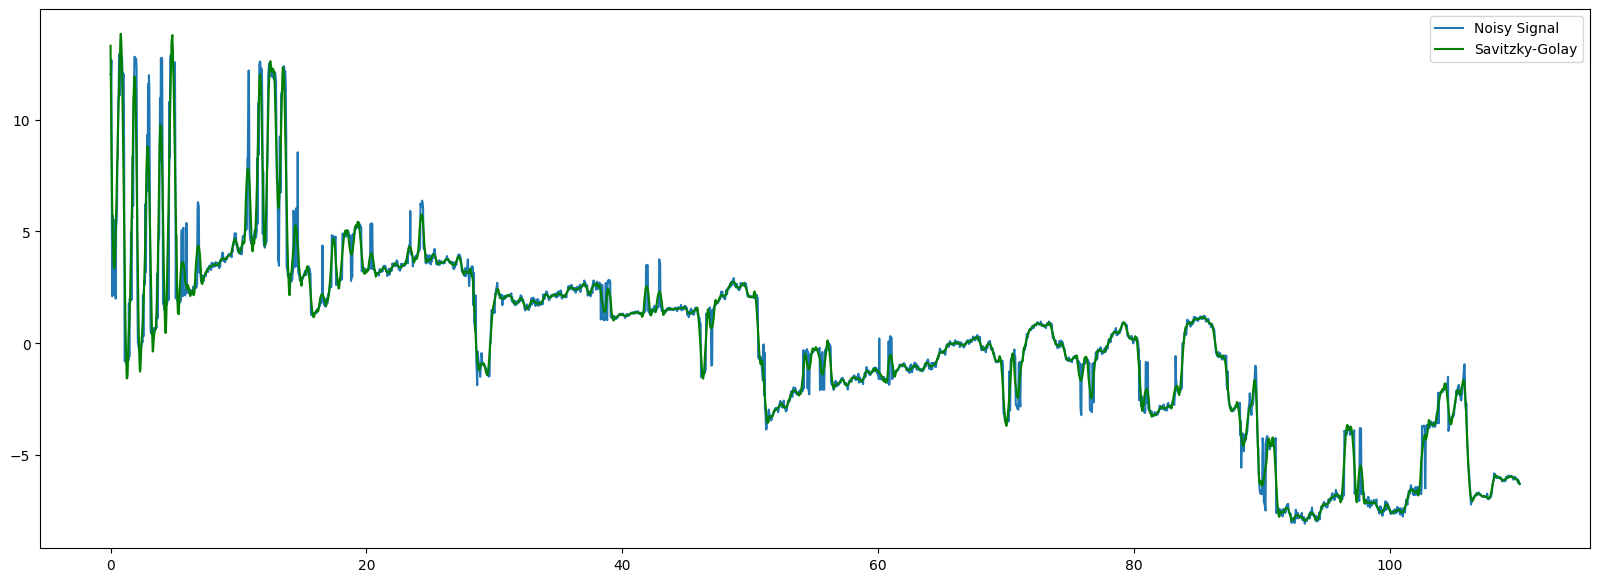

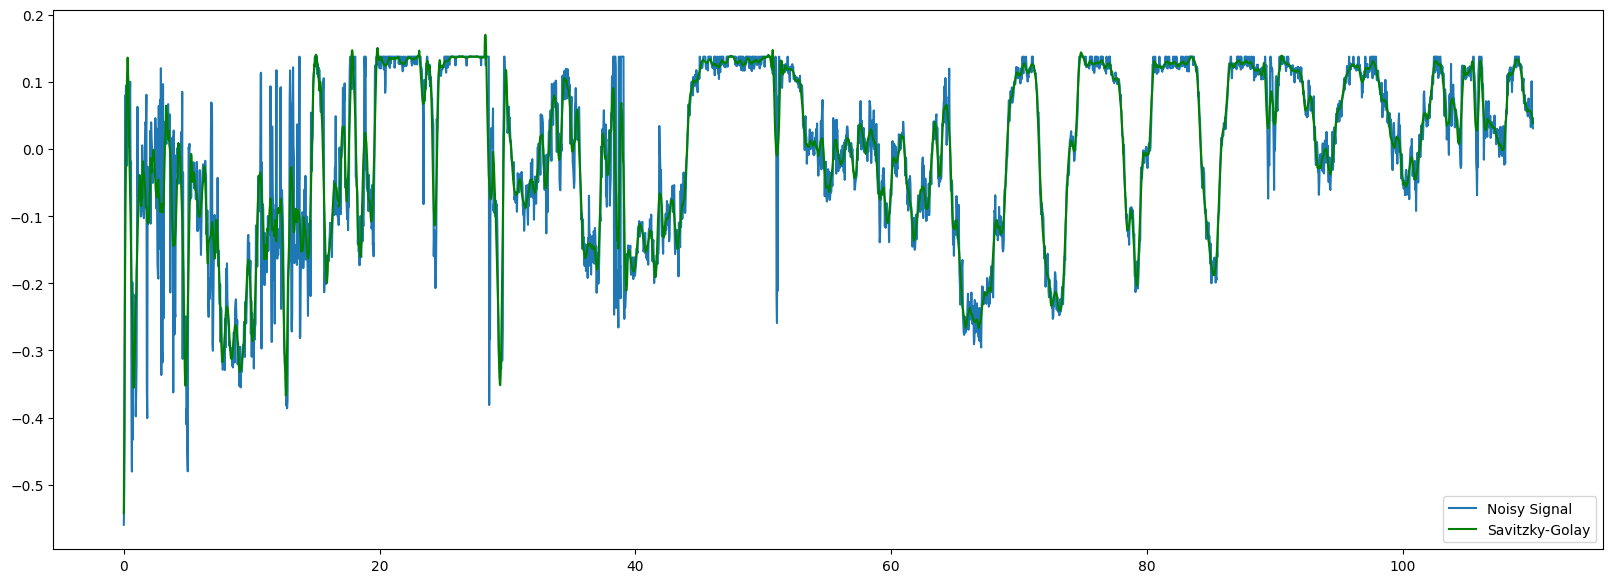

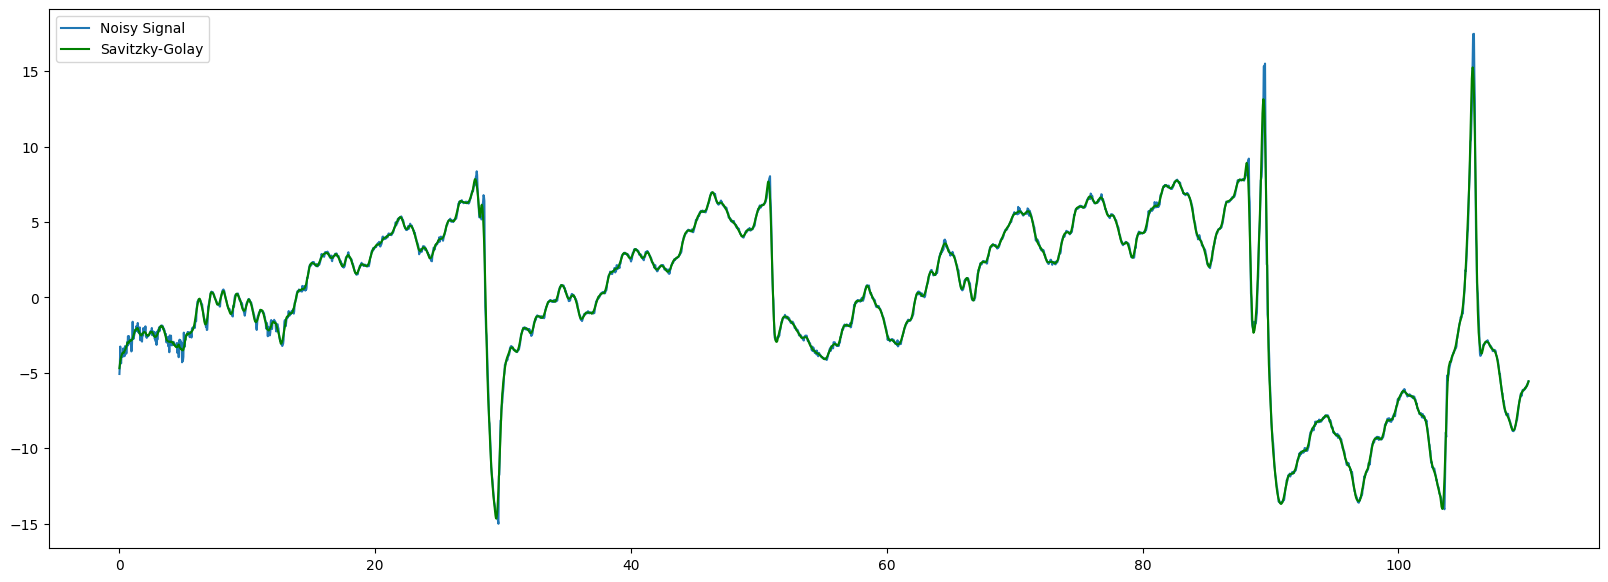

In [7]:
import scipy.signal as sig
smoothed_signal = copy.deepcopy(segnali_grezzi)

for i, col in enumerate(colors): 
    #viene applicato lo smoothing con il metodo di savitzky golay
    smoothed = savgol_filter(segnali_grezzi[i], window_length=20, polyorder=3)
    smoothed_signal[i] = smoothed
    plt.figure(figsize=(20, 7))
    t = np.arange(len(segnali_grezzi[i])) / fr
    plt.plot(t, segnali_grezzi[i], label='Noisy Signal')
    plt.plot(t, smoothed, label='Savitzky-Golay', color='green')
    plt.legend()
    plt.show()

In [8]:



def emd_like_envelope(ppg_signal, fs=fr,peak_distance_sec=0.4,prominence=0.0):
    '''

    da un segnale PPG BGR
    fs : Frame rate del video
    restituisce un dizionario con massimi minimi, inviluppi, segnale medio e la f "candidata" dell'EMD classico
    
    '''
    N = len(ppg_signal[0])
    t = np.arange(N)

    results = {}

    min_distance = int(fs * peak_distance_sec)

    for ch_idx, ch_name in enumerate(colors):

        signal = ppg_signal[ch_idx]
        # =====================================================
        # MASSIMI LOCALI
        # =====================================================
        max_idx, _ = find_peaks(
            signal,
            distance=min_distance,
            prominence=prominence
        )

        # =====================================================
        # MINIMI LOCALI
        # =====================================================
        min_idx, _ = find_peaks(
            -signal,
            distance=min_distance,
            prominence=prominence
        )

        # =====================================================
        # AGGIUNTA BORDI
        # =====================================================
        max_idx = np.unique(
            np.concatenate(([0], max_idx, [N - 1]))
        )

        min_idx = np.unique(
            np.concatenate(([0], min_idx, [N - 1]))
        )

        # =====================================================
        # ENVELOPE SUPERIORE
        # =====================================================
        upper_spline = PchipInterpolator(
            max_idx,
            signal[max_idx]
        )
        upper_env = upper_spline(t)
        lower_spline = PchipInterpolator(
            min_idx,
            signal[min_idx]
        )
        lower_env = lower_spline(t)

        # =====================================================
        # MEDIA ENVELOPE (criterio EMD)
        # =====================================================
        mean_env = (upper_env + lower_env) / 2.0

        # =====================================================
        # DETRENDING TIPO EMD
        # =====================================================
        imf_candidate = signal - mean_env

        results[ch_name] = {
            "signal": signal,
            "max_idx": max_idx,
            "min_idx": min_idx,
            "upper_envelope": upper_env,
            "lower_envelope": lower_env,
            "mean_envelope": mean_env,
            "imf_candidate": imf_candidate
        }

    return results


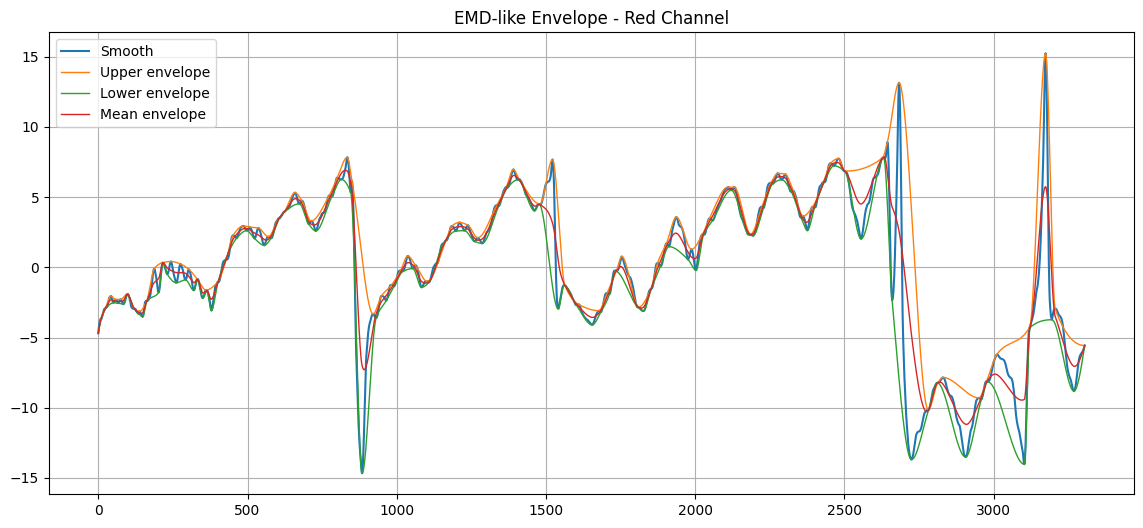

In [9]:
risultati_emd = emd_like_envelope(smoothed_signal,fs=fr)
risultati_emd_rosso = risultati_emd["red"]
plt.figure(figsize=(14, 6))

#plt.plot(smoothed_signal[:,2], alpha=0.4, label="Raw")
plt.plot(risultati_emd_rosso["signal"], label="Smooth")

plt.plot(
    risultati_emd_rosso["upper_envelope"],
    linewidth=1,
    label="Upper envelope"
)

plt.plot(
    risultati_emd_rosso["lower_envelope"],
    linewidth=1,
    label="Lower envelope"
)

plt.plot(
    risultati_emd_rosso["mean_envelope"],
    linewidth=1,
    label="Mean envelope"
)

plt.legend()
plt.grid(True)
plt.title("EMD-like Envelope - Red Channel")

plt.show()

In [10]:
breathing_signal = [[],[],[]]
#si usa il canale del rosso
for i, col in enumerate(colors):
    breathing_signal[i] = risultati_emd[col]["mean_envelope"]

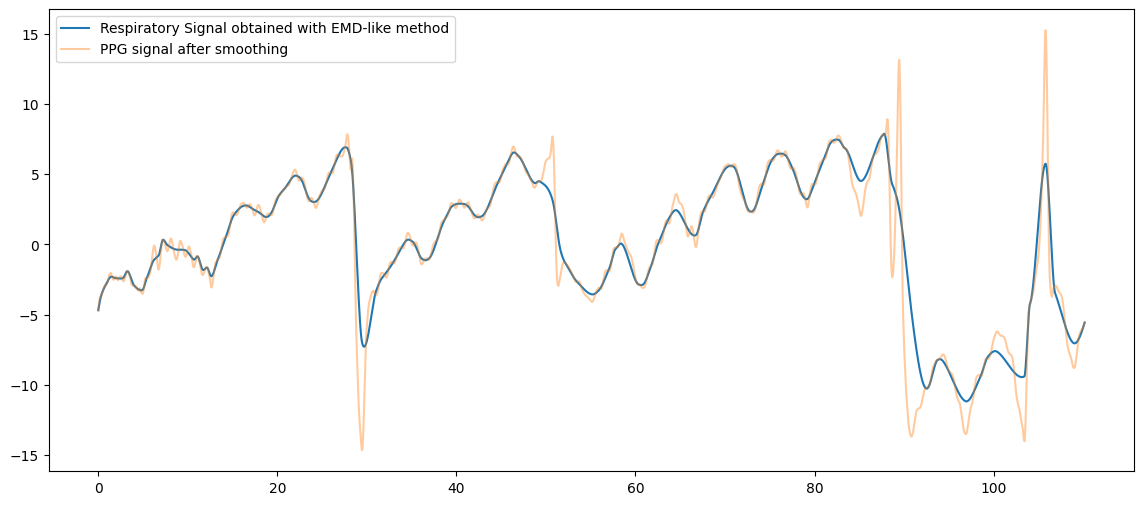

In [11]:
plt.figure(figsize=(14, 6))

plt.plot(t, breathing_signal[2],  label="Respiratory Signal obtained with EMD-like method")
#plt.plot(t, avg_color_roi[:,2], label="PPGred", alpha=0.4)
plt.plot(t, smoothed_signal[2], label="PPG signal after smoothing", alpha=0.4)
plt.legend()
plt.show()

In [12]:
from scipy.signal import periodogram, windows
import numpy as np
from scipy.signal import find_peaks

def calcola_respiratory_rate_psd(segnale, fps=30, is_globale=False):
    #calcola la PSD di un segnale scartando le finestre con artefatti
    # lunghezza segmento come nel codice originale
    durata_finestra = 30       # secondi
    n_seg = min(len(segnale), int(durata_finestra*fps))
    noverlap = n_seg // 2 #Applichiamo overlap 50%
    step = n_seg - noverlap
    punti_fft = max(2048, 2**int(np.ceil(np.log2(n_seg)))) # zero padding
    hann = windows.hann(n_seg)
    psd_list = []

    for start in range(0, len(segnale) - n_seg + 1, step):

        segmento = segnale[start:start + n_seg]
        # Scartiamo le finestre con artefatti al centro
        centro = segmento[3*n_seg//20 : 17*n_seg//20]
        sottosegmenti = np.array_split(centro, 15)
        medie = np.array([np.mean(s) for s in sottosegmenti])
        delta = np.abs(np.diff(medie))
        jump = np.max(delta)#Se il salto tra medie di sottoseg consecutivi è troppo ampio, scarto
        jump_normale = np.median(delta) 
        jump_normale = max(jump_normale, 1e-6)# evito problemi se è molto piccolo
        # criterio
        if jump > 4*jump_normale:
            continue
        frequenze, psd_segmento = periodogram(segmento, fs=fps, window=hann, detrend="linear", nfft=punti_fft,scaling="density")
        psd_list.append(psd_segmento)
    # se le finestre accettabili sono meno di due
    min_finestre = 2 if len(segnale) > n_seg else 1
    if len(psd_list) < min_finestre:
        return 0.0, 0.0, None, None, "artifact"
    # media dei periodogrammi (Welch)
    psd = np.mean(psd_list, axis=0)
    mask = (frequenze >= 0.1) & (frequenze <= 0.7)#cerco solo le f in banda
    frequenze_respiro = frequenze[mask]
    psd_respiro = psd[mask]
    peaks, properties = find_peaks(psd_respiro)

    if len(peaks) == 0:
        return 0.0, 0.0, frequenze, psd
    altezze = psd_respiro[peaks]
    idx_sorted = np.argsort(altezze)[::-1]

    picco1 = peaks[idx_sorted[0]]
    amp1 = psd_respiro[picco1]
    f1 = frequenze_respiro[picco1]
    resp_rate = f1 * 60
    f_scelta = f1
    return resp_rate, f_scelta, frequenze, psd, "ok"

    



--- ANALISI BR A FINESTRE (30 SECONDI) ---
Window 0s - 30s: RR = 8.79 bpm [Accepted]
Window 15s - 45s: RR = 0.00 bpm [Rejected: artifact]
Window 30s - 60s: RR = 10.55 bpm [Accepted]
Window 45s - 75s: RR = 8.79 bpm [Accepted]
Window 60s - 90s: RR = 9.67 bpm [Accepted]
Window 75s - 105s: RR = 0.00 bpm [Rejected: artifact]

--- FINAL RESPIRATORY RATE ESTIMATION ---
1. Mean over ALL 30-s windows:          6.30 bpm
2. Mean over ACCEPTED windows:          9.45 bpm (based on 4/6 windows)
3. Global estimate (whole signal): 9.67 rpm (0.161 Hz) [ok]



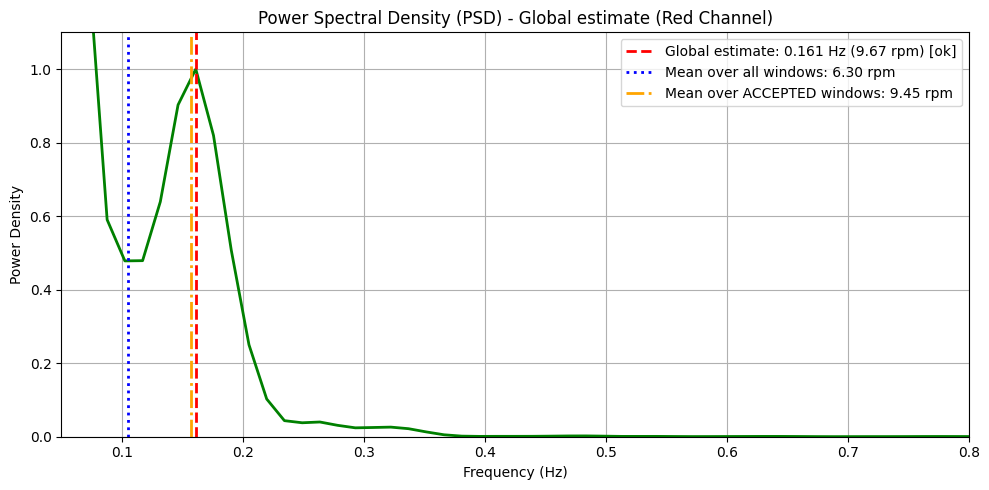

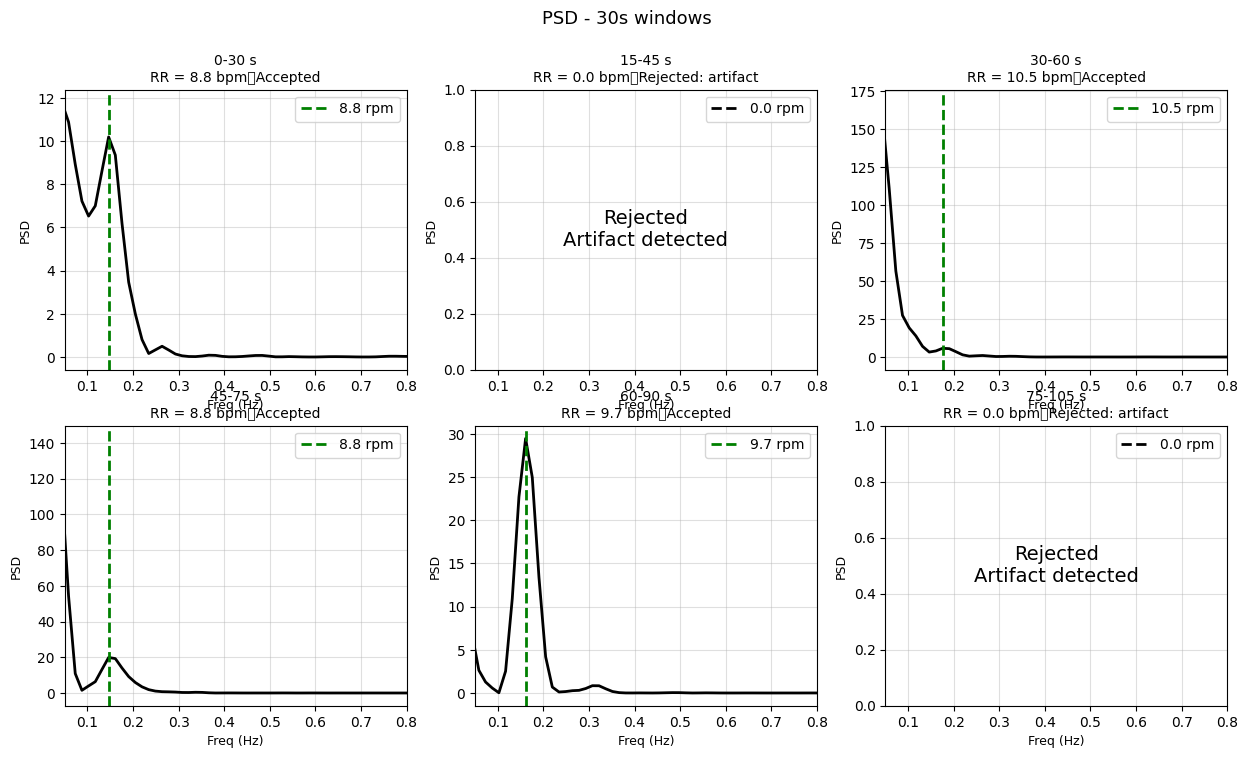

In [14]:
segnale_rosso_analisi = breathing_signal[2]

# 1. Analisi a finestre di 30 secondi
finestra_frame = 30 * fr
print("\n--- ANALISI BR A FINESTRE (30 SECONDI) ---")

br_finestre = [] # Tutte le finestre
br_finestre_valide = [] # Solo le finestre nel range 7.5 - 20.5
dati_finestre_plot = [] 

step_frame = finestra_frame // 2   # overlap 50%

for start in range(0, len(segnale_rosso_analisi) - finestra_frame + 1, step_frame):

    end = start + finestra_frame

    chunk_segnale = segnale_rosso_analisi[start:end]
    
    br_chunk, f_picco_chunk, freq_chunk, psd_chunk, quality = \
        calcola_respiratory_rate_psd(
            chunk_segnale,
            fps=fr,
            is_globale=False
        )
    br_finestre.append(br_chunk) 
    
    # Controllo fisiologico 
    if quality == "artifact":
        status = "Rejected: artifact"

    elif 0.05*60 <= br_chunk <= 0.7*60:
        status = "Accepted"
        br_finestre_valide.append(br_chunk)

    else:
        status = "Rejected: RR out of range"
        
    print(f"Window {start//fr}s - {end//fr}s: "f"RR = {br_chunk:.2f} bpm [{status}]")
    
    dati_finestre_plot.append({
        'start': start//fr,
        'end': min(end, len(segnale_rosso_analisi))//fr,
        'br': br_chunk,
        'f_picco': f_picco_chunk,
        'freq': freq_chunk,
        'psd': psd_chunk,
        'status': status
    })

# Calcolo delle medie
media_finestre_30s = np.mean(br_finestre) if len(br_finestre) > 0 else 0.0
media_finestre_valide_30s = np.mean(br_finestre_valide) if len(br_finestre_valide) > 0 else 0.0

# 2. Analisi Globale (Tutto il segnale unito)
rr_bpm_globale, f_picco_glob, freq_glob, psd_glob, status_globale = calcola_respiratory_rate_psd(segnale_rosso_analisi, fps=fr, is_globale=True)
if not(6 <= rr_bpm_globale <= 42):
 status_globale = "Rejected (out of range)" 
n_ok = sum(d['status']=="Accepted" for d in dati_finestre_plot)
n_art = sum(d['status']=="Rejected: artifact" for d in dati_finestre_plot)
n_rr = sum(d['status']=="Rejected: RR out of range" for d in dati_finestre_plot)
print("\n--- FINAL RESPIRATORY RATE ESTIMATION ---")
print(f"1. Mean over ALL 30-s windows:          {media_finestre_30s:.2f} bpm")
if len(br_finestre_valide) > 0:
    print(f"2. Mean over ACCEPTED windows:          "f"{media_finestre_valide_30s:.2f} bpm "f"(based on {len(br_finestre_valide)}/{len(br_finestre)} windows)"
)
else:
    print(f"2. Mean over ACCEPTED windows:     N/A (No window within physiologic range 6-42)")
print(f"3. Global estimate (whole signal): {rr_bpm_globale:.2f} rpm ({f_picco_glob:.3f} Hz) [{status_globale}]\n")

# GRAFICO 2: PSD Globale
fig_br = plt.figure(figsize=(10, 5))
idx_resp = (freq_glob >= 0.1) & (freq_glob <= 0.7)
max_resp = np.max(psd_glob[idx_resp])
psd_norm = psd_glob / max_resp
plt.plot(freq_glob, psd_norm, color='green', linewidth=2)
plt.ylim(0, 1.1)
plt.axvline(x=f_picco_glob, color='red', linestyle='--', linewidth=2, 
            label=f'Global estimate: {f_picco_glob:.3f} Hz ({rr_bpm_globale:.2f} rpm) [{status_globale}]')
plt.axvline(x=(media_finestre_30s/60.0), color='blue', linestyle=':', linewidth=2, 
            label=f'Mean over all windows: {media_finestre_30s:.2f} rpm')

# Aggiungo la linea per la media delle sole finestre valide (se ce n'è almeno una)
if len(br_finestre_valide) > 0:
    plt.axvline(x=(media_finestre_valide_30s/60.0), color='orange', linestyle='-.', linewidth=2, 
                label=f'Mean over ACCEPTED windows: {media_finestre_valide_30s:.2f} rpm')

plt.xlim(0.05, 0.8) 
plt.title("Power Spectral Density (PSD) - Global estimate (Red Channel)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Density")
plt.legend()
plt.grid(True)
plt.tight_layout()

# GRAFICO 3: Griglia delle singole finestre da 30 secondi "Affiancate"
num_finestre = len(dati_finestre_plot)
if num_finestre > 0:
    cols = min(3, num_finestre)
    rows = int(np.ceil(num_finestre / cols))
    
    fig_grid, axes_grid = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    fig_grid.suptitle("PSD - 30s windows", fontsize=13)
    
    if num_finestre == 1:
        axes_grid = [axes_grid]
    else:
        axes_grid = axes_grid.flatten()
        
    for idx, d in enumerate(dati_finestre_plot):
        ax = axes_grid[idx]
        if d['freq'] is not None and d['psd'] is not None:
            ax.plot(d['freq'], d['psd'], color='black', linewidth=2)
        if d['status'] == "Accepted":
            line_color = 'green'

        elif d['status'] == "Rejected: artifact":
            line_color = 'black'
            ax.text(
            0.5,
            0.5,
            "Rejected\nArtifact detected",
            ha='center',
            va='center',
            fontsize=14,
            color='black',
            transform=ax.transAxes
            )

            ax.set_xlim(0.05,0.8)
            ax.set_ylim(0,1)
            ax.grid(True, alpha=0.4)

        
        
        
        ax.axvline(x=d['f_picco'], color=line_color, linestyle='--', linewidth=2, 
                   label=f"{d['br']:.1f} rpm")
                   
        ax.set_title(f"{d['start']}-{d['end']} s\nRR = {d['br']:.1f} bpm\t{d['status']}", fontsize=10)
        ax.set_xlim(0.05, 0.8)
        ax.set_xlabel("Freq (Hz)", fontsize=9)
        ax.set_ylabel("PSD", fontsize=9)
        ax.grid(True, alpha=0.4)
        ax.legend(loc='upper right', fontsize=10)
        
    for idx in range(num_finestre, len(axes_grid)):
        fig_grid.delaxes(axes_grid[idx])
        
    

plt.show()